In [49]:
from datetime import datetime, timedelta, timezone
import time
from typing import List, Dict, Union, Any
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import ccxt

from siglab_py.util.market_data_util import fetch_candles

In [50]:
exchange = ccxt.binance({
    'options': {'defaultType': 'linear'},
    'enableRateLimit': True,
})

normalized_symbols = [ 'BTC/USDT:USDT' ]

start_date : datetime = datetime(2026,1,1)
end_date : datetime = datetime(2026,3,17)

### Fetch candles

In [51]:
pd_candles: Union[pd.DataFrame, None] = fetch_candles(
    start_ts=start_date.timestamp(),
    end_ts=end_date.timestamp(),
    exchange=exchange,
    normalized_symbols=normalized_symbols,
    candle_size='1h'
)[normalized_symbols[0]]

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:316: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]


In [52]:
pd_candles

,exchange,symbol,timestamp_ms,open,high,low,close,volume,datetime,datetime_utc,...,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr,pct_chg_on_close
0,Binance,BTC/USDT:USDT,1767196800000,87909.0,88024.3,87350.5,87625.9,12077.887,2026-01-01 00:00:00,2025-12-31 16:00:00+00:00,...,1,1,0,0,3,2,False,True,False,NaN
1,Binance,BTC/USDT:USDT,1767200400000,87625.9,87716.0,87454.0,87587.2,4255.614,2026-01-01 01:00:00,2025-12-31 17:00:00+00:00,...,1,1,1,0,3,2,False,True,False,-0.000442
2,Binance,BTC/USDT:USDT,1767204000000,87587.2,87952.0,87535.0,87655.8,5108.155,2026-01-01 02:00:00,2025-12-31 18:00:00+00:00,...,1,1,2,0,3,2,False,True,False,0.000783
3,Binance,BTC/USDT:USDT,1767207600000,87655.9,87846.0,87454.0,87515.0,2612.319,2026-01-01 03:00:00,2025-12-31 19:00:00+00:00,...,1,1,3,0,3,2,False,True,False,-0.001606
4,Binance,BTC/USDT:USDT,1767211200000,87515.0,87683.6,87189.2,87629.0,6228.769,2026-01-01 04:00:00,2025-12-31 20:00:00+00:00,...,1,1,4,0,3,2,False,True,False,0.001303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,Binance,BTC/USDT:USDT,1773658800000,73745.5,73856.6,73466.3,73515.3,5218.038,2026-03-16 19:00:00,2026-03-16 11:00:00+00:00,...,3,16,19,0,0,2,False,True,False,-0.003122
1796,Binance,BTC/USDT:USDT,1773662400000,73515.3,74043.0,73420.4,73830.0,10877.388,2026-03-16 20:00:00,2026-03-16 12:00:00+00:00,...,3,16,20,0,0,2,False,True,False,0.004281
1797,Binance,BTC/USDT:USDT,1773666000000,73830.0,74481.5,73746.3,74075.0,16330.868,2026-03-16 21:00:00,2026-03-16 13:00:00+00:00,...,3,16,21,0,0,2,False,True,False,0.003318
1798,Binance,BTC/USDT:USDT,1773669600000,74075.0,74450.0,72926.4,73519.8,25291.011,2026-03-16 22:00:00,2026-03-16 14:00:00+00:00,...,3,16,22,0,0,2,False,True,False,-0.007495


### Fetch Funding Rate

In [53]:
since = int(start_date.timestamp() *1000)

funding_history = exchange.fetchFundingRateHistory(normalized_symbols[0], since=since, limit=500)  # adjust limit as supported
funding_history = [ {
    'datetime_utc' : datetime.fromtimestamp(int(entry['timestamp']/1000), tz=timezone.utc),
    'timestamp_ms' : entry['timestamp'],
    'funding_rate_interval' : round(entry['fundingRate'] *100, 2),
    'funding_rate_annualized' : round(entry['fundingRate'] *100 *3 *365, 2),
    } for entry in funding_history ]
pd_funding_history = pd.DataFrame(funding_history)
pd_funding_history.sort_values(by=['timestamp_ms'], ascending=[ False ], inplace=True)
pd_funding_history

,datetime_utc,timestamp_ms,funding_rate_interval,funding_rate_annualized
229,2026-03-18 00:00:00+00:00,1773792000002,-0.01,-7.19
228,2026-03-17 16:00:00+00:00,1773763200011,-0.00,-1.38
227,2026-03-17 08:00:00+00:00,1773734400002,-0.00,-2.74
226,2026-03-17 00:00:00+00:00,1773705600000,0.00,0.26
225,2026-03-16 16:00:00+00:00,1773676800000,0.00,2.21
...,...,...,...,...
4,2026-01-02 00:00:00+00:00,1767312000006,0.01,6.14
3,2026-01-01 16:00:00+00:00,1767283200001,0.00,1.87
2,2026-01-01 08:00:00+00:00,1767254400002,0.01,10.95
1,2026-01-01 00:00:00+00:00,1767225600008,0.01,10.95


In [54]:
avg_funding_rate_annualized = round(pd_funding_history['funding_rate_annualized'].mean(), 2)
avg_funding_rate_annualized

np.float64(1.59)

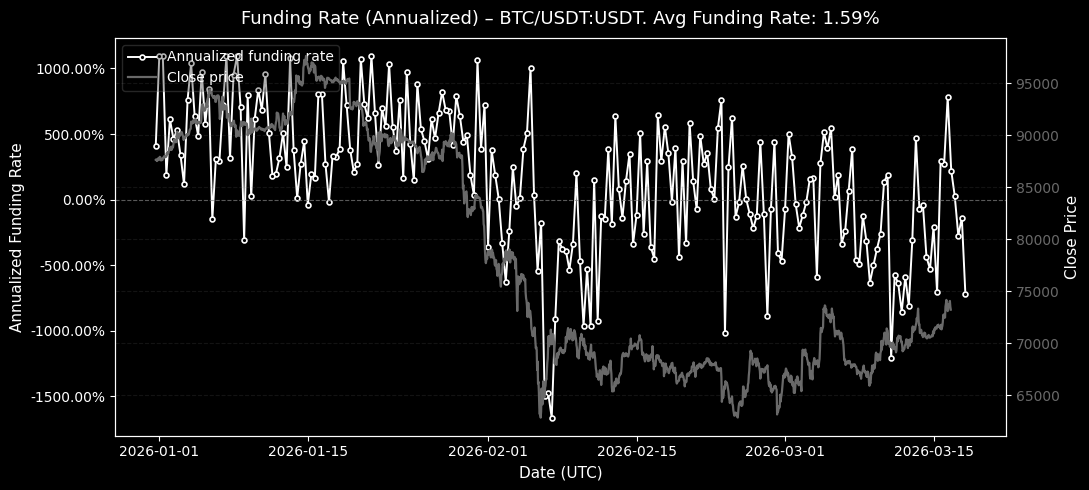

In [55]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    pd_funding_history['datetime_utc'],
    pd_funding_history['funding_rate_annualized'],
    color='white',
    linewidth=1.4,
    marker='o',
    markersize=3.5,
    markerfacecolor='black',
    markeredgecolor='white',
    markeredgewidth=1.2,
    label='Annualized funding rate'
)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Date (UTC)', fontsize=11)
ax1.set_ylabel('Annualized Funding Rate', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.2f}%'))
ax1.tick_params(axis='y', labelcolor='white')

ax2 = ax1.twinx()
ax2.plot(
    pd_candles['datetime_utc'],
    pd_candles['close'],
    color='dimgray',
    linewidth=1.6,
    label='Close price'
)
ax2.set_ylabel('Close Price', fontsize=11)
ax2.tick_params(axis='y', labelcolor='dimgray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.3, facecolor='black', edgecolor='gray')

plt.title(f'Funding Rate (Annualized) – {normalized_symbols[0]}. Avg Funding Rate: {avg_funding_rate_annualized}%', fontsize=13, pad=10)
plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

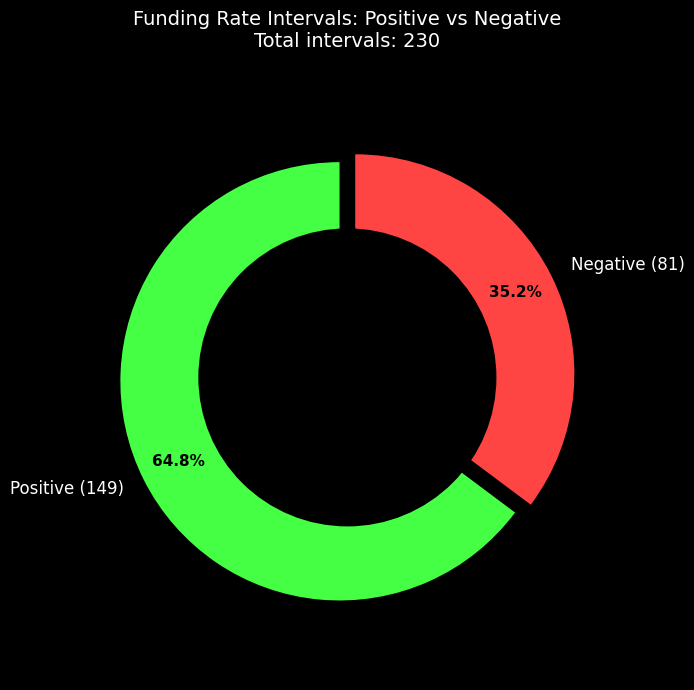

In [56]:

plt.style.use('dark_background')

positive = (pd_funding_history['funding_rate_annualized'] > 0).sum()
negative = (pd_funding_history['funding_rate_annualized'] < 0).sum()
zero = len(pd_funding_history) - positive - negative

labels = []
sizes = []
colors = []

if positive > 0:
    labels.append(f'Positive ({positive})')
    sizes.append(positive)
    colors.append('#44ff44')

if negative > 0:
    labels.append(f'Negative ({negative})')
    sizes.append(negative)
    colors.append('#ff4444')

if zero > 0:
    labels.append(f'Zero ({zero})')
    sizes.append(zero)
    colors.append('#777777')

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    explode=[0.04] * len(sizes),
    shadow=False,
    textprops={'fontsize': 12, 'color': 'white'},
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.axis('equal')

plt.title('Funding Rate Intervals: Positive vs Negative\n'
          f'Total intervals: {len(pd_funding_history)}', 
          fontsize=14, pad=20)

centre_circle = plt.Circle((0,0), 0.68, fc='black')
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()